In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, silhouette_score

import shap
%matplotlib inline
warnings.filterwarnings('ignore')

In [2]:
BASE_DIR = "../"
DATA_PATH = os.path.join(BASE_DIR, "data", "cancer_data_eng.csv")
IMG_DIR = os.path.join(BASE_DIR, "img")
RESULTS_DIR = os.path.join(BASE_DIR, "results")

os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
RANDOM_STATE = 42
N_SAMPLES = 10000

In [3]:
print("\n[0] 加载数据...")
df = pd.read_csv(DATA_PATH, low_memory=False, encoding='latin-1')
df['target'] = df['Status.Vital'].map({'VIVO': 1, 'MORTO': 0})
df = df.dropna(subset=['target'])
np.random.seed(RANDOM_STATE)
if len(df) > N_SAMPLES:
    idx = np.random.choice(len(df), N_SAMPLES, replace=False)
    df = df.iloc[idx].copy()

feature_cols = ['Age', 'year', 'Code.Profession', 'Diagnostic.means',
                'Extension', 'Raca.Color']
df_feat = df[feature_cols + ['target']].copy()

cat_cols = ['Diagnostic.means', 'Extension', 'Raca.Color']
for col in cat_cols:
    le = LabelEncoder()
    non_null = df_feat[col].dropna().astype(str)
    le.fit(non_null)
    mc = non_null.value_counts().index[0]
    def encode(x, le=le, mc=mc):
        if pd.isna(x): return np.nan
        xs = str(x)
        return le.transform([xs])[0] if xs in le.classes_ else le.transform([mc])[0]
    df_feat[col] = df_feat[col].apply(encode)

X = df_feat[feature_cols].astype(float).values
y = df_feat['target'].values
feature_names = np.array(feature_cols)

print(f"    总样本: {len(X):,}  VIVO: {y.sum():,} ({y.mean()*100:.2f}%)")

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)

imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()
X_tr_imp = imputer.fit_transform(X_tr)
X_te_imp = imputer.transform(X_te)
X_tr_final = scaler.fit_transform(X_tr_imp)
X_te_final = scaler.transform(X_te_imp)



[0] 加载数据...
    总样本: 10,000  VIVO: 4,123.0 (41.23%)


In [4]:
print("\n[1] 训练 Random Forest + SHAP TreeExplainer...")
model = RandomForestClassifier(
    n_estimators=200, max_depth=8, class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1)
model.fit(X_tr_final, y_tr)
auc = roc_auc_score(y_te, model.predict_proba(X_te_final)[:, 1])
print(f"    RF AUC = {auc:.4f}")

X_shap = X_te_final[:]  # 整个测试集用于 SHAP 聚类 (更多样本使聚类更可靠)
y_shap = y_te[:]

explainer = shap.TreeExplainer(model)
sv_full = explainer.shap_values(X_shap)

if isinstance(sv_full, list):
    sv = sv_full[1]
else:
    sv = sv_full
    if sv.ndim == 3:
        sv = sv[:, :, 1]

shap_importance = np.abs(sv).mean(0)
feature_order = np.argsort(shap_importance)[::-1]
print(f"    SHAP 形状: {sv.shape}")
print(f"    特征排名: {[feature_names[i] for i in feature_order]}")


[1] 训练 Random Forest + SHAP TreeExplainer...
    RF AUC = 0.9104
    SHAP 形状: (3000, 6)
    特征排名: [np.str_('Diagnostic.means'), np.str_('year'), np.str_('Raca.Color'), np.str_('Extension'), np.str_('Code.Profession'), np.str_('Age')]


In [5]:
# 确定最佳聚类数: 2~5
best_n = 3  # 默认
best_score = -1
silhouette_scores = {}

for n in range(2, 6):
    km = KMeans(n_clusters=n, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(sv)
    score = silhouette_score(sv, labels)
    silhouette_scores[n] = score
    print(f"    n_clusters={n}:  Silhouette Score = {score:.4f}")

best_n = max(silhouette_scores, key=silhouette_scores.get)
print(f"\n    → 最佳聚类数: {best_n} (Silhouette Score={silhouette_scores[best_n]:.4f})")

kmeans = KMeans(n_clusters=best_n, random_state=RANDOM_STATE, n_init=10)
clusters = kmeans.fit_predict(sv)

# PCA 降维用于可视化
pca = PCA(n_components=2, random_state=RANDOM_STATE)
sv_pca = pca.fit_transform(sv)
print(f"    PCA 方差解释率: PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%}")
print(f"    累积: {pca.explained_variance_ratio_.sum():.2%}")


    n_clusters=2:  Silhouette Score = 0.6209
    n_clusters=3:  Silhouette Score = 0.6205
    n_clusters=4:  Silhouette Score = 0.5692
    n_clusters=5:  Silhouette Score = 0.5393

    → 最佳聚类数: 2 (Silhouette Score=0.6209)
    PCA 方差解释率: PC1=70.11%, PC2=19.17%
    累积: 89.28%


  [图] 19a_shap_clustering_panel.png 已保存


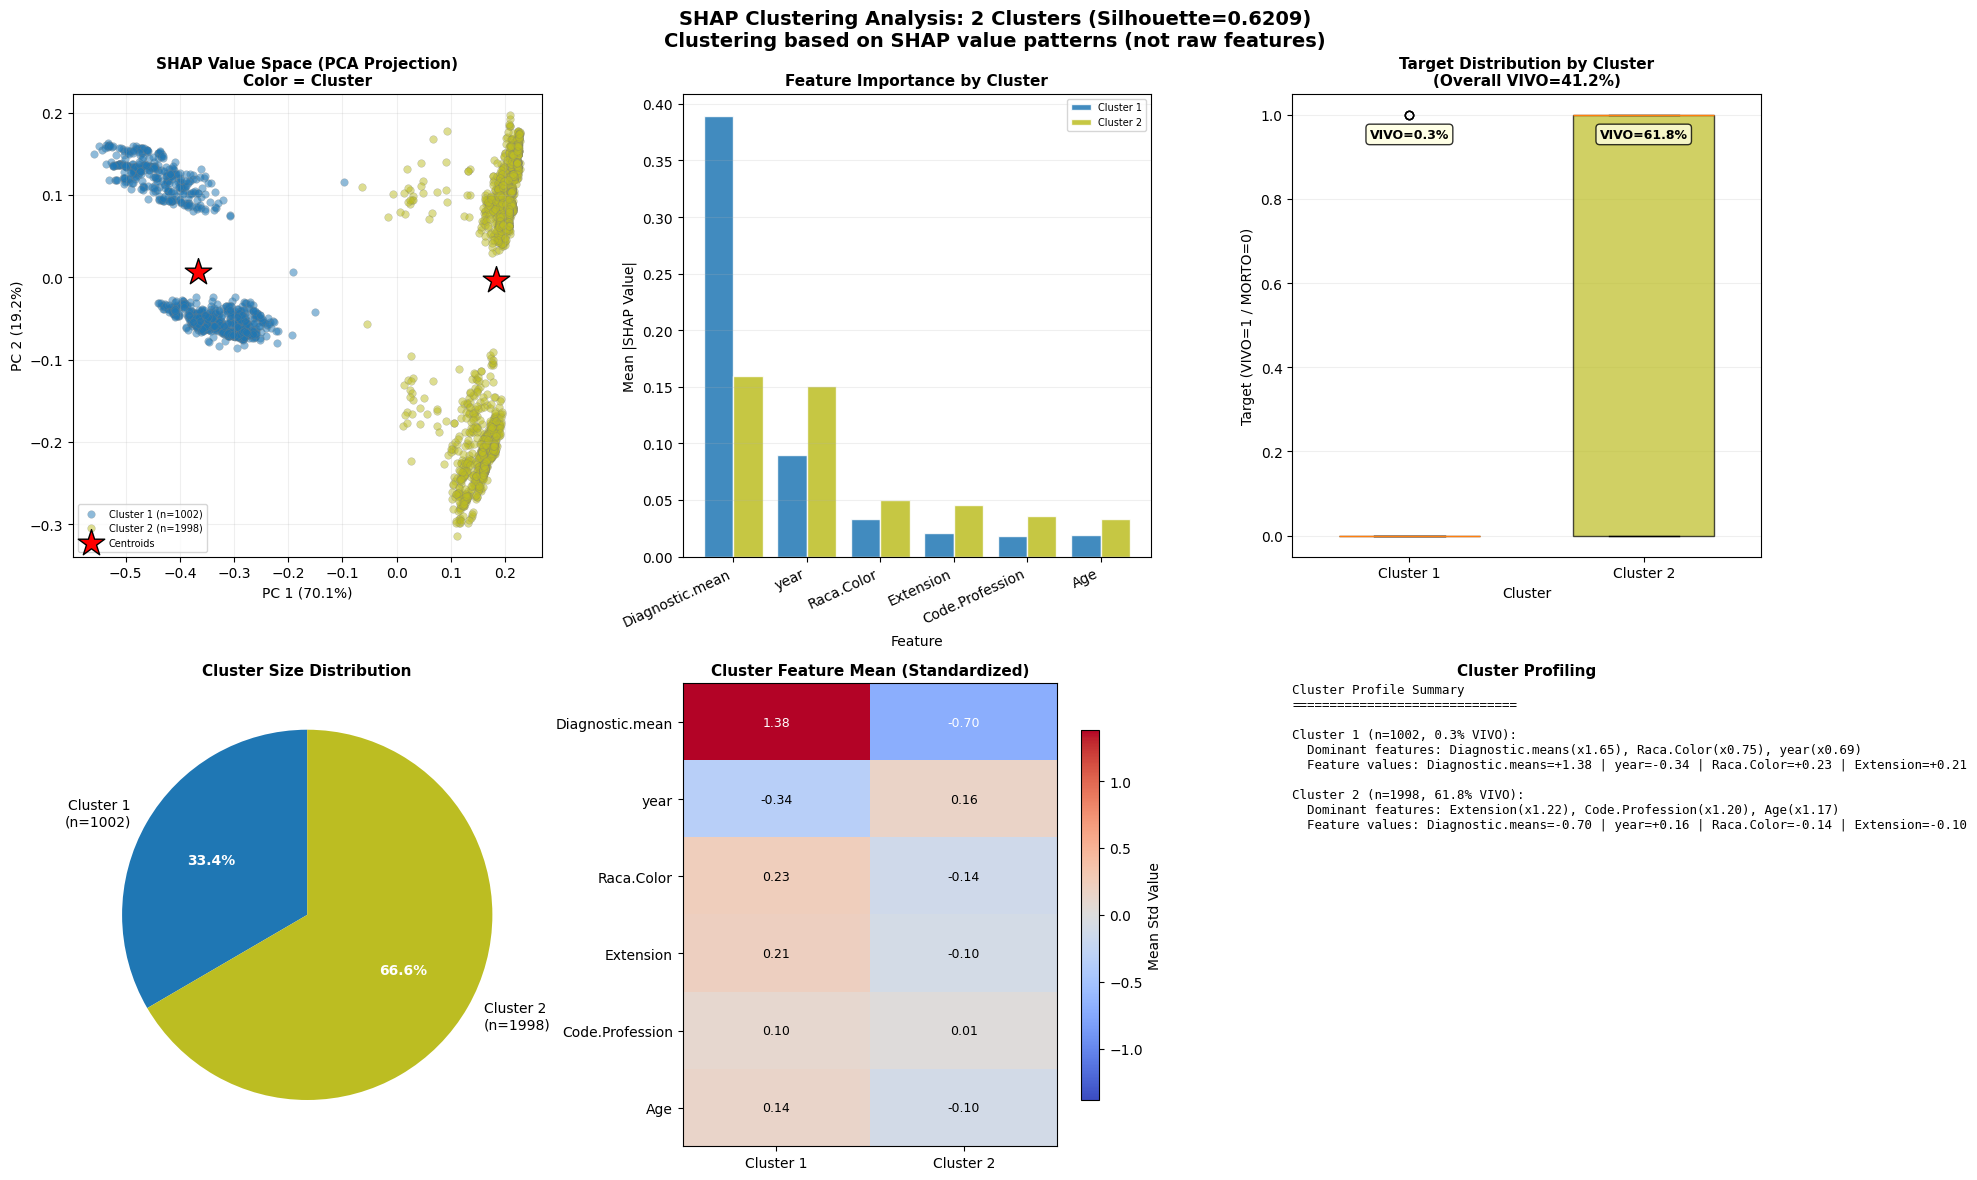

In [6]:
cluster_colors = plt.cm.tab10(np.linspace(0, 0.8, best_n))

fig = plt.figure(figsize=(20, 12))
fig.suptitle(f'SHAP Clustering Analysis: {best_n} Clusters (Silhouette={silhouette_scores[best_n]:.4f})'
             f'\nClustering based on SHAP value patterns (not raw features)',
             fontsize=14, fontweight='bold')

# === 子图 1: PCA 投影 → SHAP 空间的聚类结构 ===
ax1 = plt.subplot(2, 3, 1)
for c in range(best_n):
    mask = clusters == c
    ax1.scatter(sv_pca[mask, 0], sv_pca[mask, 1],
                c=[cluster_colors[c]], s=30, alpha=0.5,
                edgecolors='gray', linewidth=0.3,
                label=f'Cluster {c+1} (n={mask.sum()})')

centers_pca = pca.transform(kmeans.cluster_centers_)
ax1.scatter(centers_pca[:, 0], centers_pca[:, 1],
            c='red', marker='*', s=400, edgecolors='black', linewidth=1,
            label='Centroids', zorder=5)
ax1.set_xlabel(f'PC 1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=10)
ax1.set_ylabel(f'PC 2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=10)
ax1.set_title('SHAP Value Space (PCA Projection)\nColor = Cluster',
              fontsize=11, fontweight='bold')
ax1.legend(fontsize=7, loc='best')
ax1.grid(True, alpha=0.2)

# === 子图 2: 聚类特征重要性对比 (分组条形图) ===
ax2 = plt.subplot(2, 3, 2)
cluster_mean_shap = []
for c in range(best_n):
    mask = clusters == c
    mean_shap = np.abs(sv[mask]).mean(axis=0)
    cluster_mean_shap.append(mean_shap)

top_n_feat = min(6, len(feature_names))
top_feat_idx = feature_order[:top_n_feat]
x = np.arange(len(top_feat_idx))
width = 0.8 / best_n

for c in range(best_n):
    values = [cluster_mean_shap[c][idx] for idx in top_feat_idx]
    ax2.bar(x + c * width, values, width,
            label=f'Cluster {c+1}', color=cluster_colors[c], alpha=0.85, edgecolor='white')

ax2.set_xlabel('Feature', fontsize=10)
ax2.set_ylabel('Mean |SHAP Value|', fontsize=10)
ax2.set_title('Feature Importance by Cluster',
              fontsize=11, fontweight='bold')
ax2.set_xticks(x + width * (best_n - 1) / 2)
ax2.set_xticklabels([feature_names[idx][:15] for idx in top_feat_idx], rotation=25, ha='right')
ax2.legend(fontsize=7)
ax2.grid(True, alpha=0.2, axis='y')

# === 子图 3: 目标分布 (VIVO 比例) per cluster ===
ax3 = plt.subplot(2, 3, 3)
cluster_target_data = []
cluster_vivo_pct = []
for c in range(best_n):
    mask = clusters == c
    cluster_target_data.append(y_shap[mask])
    vivo_pct = y_shap[mask].mean() * 100
    cluster_vivo_pct.append(vivo_pct)

bp = ax3.boxplot(cluster_target_data, labels=[f'Cluster {c+1}' for c in range(best_n)],
                 patch_artist=True, widths=0.6)
for patch, color in zip(bp['boxes'], cluster_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# 叠加 VIVO 比例标注
for c in range(best_n):
    ax3.text(c + 1, ax3.get_ylim()[1] * 0.9,
             f'VIVO={cluster_vivo_pct[c]:.1f}%',
             ha='center', fontsize=9, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

ax3.set_xlabel('Cluster', fontsize=10)
ax3.set_ylabel('Target (VIVO=1 / MORTO=0)', fontsize=10)
ax3.set_title(f'Target Distribution by Cluster\n(Overall VIVO={y.mean()*100:.1f}%)',
              fontsize=11, fontweight='bold')
ax3.grid(True, alpha=0.2, axis='y')

# === 子图 4: 聚类大小饼图 ===
ax4 = plt.subplot(2, 3, 4)
cluster_sizes = [np.sum(clusters == c) for c in range(best_n)]
wedges, texts, autotexts = ax4.pie(
    cluster_sizes,
    labels=[f'Cluster {c+1}\n(n={cluster_sizes[c]})' for c in range(best_n)],
    colors=cluster_colors, autopct='%1.1f%%',
    startangle=90, pctdistance=0.6)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')
ax4.set_title('Cluster Size Distribution', fontsize=11, fontweight='bold')

# === 子图 5: 聚类特征均值热图 (竖版) ===
ax5 = plt.subplot(2, 3, 5)
n_feat_heat = min(6, len(feature_names))
top_heat_idx = feature_order[:n_feat_heat]
cluster_mean_feat = np.zeros((best_n, n_feat_heat))
for c in range(best_n):
    mask = clusters == c
    cluster_mean_feat[c] = X_shap[mask][:, top_heat_idx].mean(axis=0)

vmax = max(abs(cluster_mean_feat.max()), abs(cluster_mean_feat.min()))
im = ax5.imshow(cluster_mean_feat.T, cmap='coolwarm', aspect='auto', vmin=-vmax, vmax=vmax)
ax5.set_yticks(range(n_feat_heat))
ax5.set_yticklabels([feature_names[idx][:15] for idx in top_heat_idx])
ax5.set_xticks(range(best_n))
ax5.set_xticklabels([f'Cluster {c+1}' for c in range(best_n)])
ax5.set_title('Cluster Feature Mean (Standardized)',
              fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax5, label='Mean Std Value', shrink=0.8)
for i in range(n_feat_heat):
    for j in range(best_n):
        val = cluster_mean_feat[j, i]
        text_color = 'white' if abs(val) > vmax * 0.5 else 'black'
        ax5.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=9, color=text_color)

# === 子图 6: 聚类画像表 (文字) ===
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')
profile_lines = ["Cluster Profile Summary", "=" * 30]
for c in range(best_n):
    mask = clusters == c
    n = mask.sum()
    vivo_pct = y_shap[mask].mean() * 100
    # 找出该聚类中最重要的特征 (区别于其他聚类)
    this_imp = np.abs(sv[mask]).mean(axis=0)  # (n_features,)
    global_imp = np.abs(sv).mean(axis=0)
    # 相对重要性: 该聚类 vs 全局
    rel_imp = this_imp / (global_imp + 1e-8)
    # 相对重要性最高的特征
    top_rel_idx = np.argsort(rel_imp)[::-1][:3]
    top_rel_feats = [f"{feature_names[i]}(x{rel_imp[i]:.2f})" for i in top_rel_idx]

    # 显著高于全局的特征
    profile_lines.append(f"\nCluster {c+1} (n={n}, {vivo_pct:.1f}% VIVO):")
    profile_lines.append(f"  Dominant features: {', '.join(top_rel_feats)}")
    # 特征均值倾向
    feat_tend = []
    for idx in top_heat_idx:
        mean_val = cluster_mean_feat[c, list(top_heat_idx).index(idx)]
        feat_tend.append(f"{feature_names[idx]}={mean_val:+.2f}")
    profile_lines.append(f"  Feature values: {' | '.join(feat_tend[:4])}")

ax6.text(0, 1, '\n'.join(profile_lines), transform=ax6.transAxes,
         fontsize=9, fontfamily='monospace', va='top', ha='left')
ax6.set_title('Cluster Profiling', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "19a_shap_clustering_panel.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 19a_shap_clustering_panel.png 已保存")

In [7]:
print(f"\n{'Cluster':<12} {'Size':>8} {'%':>8} {'VIVO%':>8} {'MORTO%':>8} {'Top Features (rel. to global)':<40}")
print(f"{'-'*12} {'-'*8} {'-'*8} {'-'*8} {'-'*8} {'-'*40}")
for c in range(best_n):
    mask = clusters == c
    n = mask.sum()
    pct = n / len(clusters) * 100
    vivo_pct = y_shap[mask].mean() * 100
    morto_pct = 100 - vivo_pct

    this_imp = np.abs(sv[mask]).mean(axis=0)
    global_imp = np.abs(sv).mean(axis=0)
    rel_imp = this_imp / (global_imp + 1e-8)
    top_rel_idx = np.argsort(rel_imp)[::-1][:3]
    top_str = ', '.join([f"{feature_names[i]} ({rel_imp[i]:.2f}x)" for i in top_rel_idx])

    print(f"  Cluster {c+1:<6} {n:>8} {pct:>7.1f}% {vivo_pct:>7.1f}% {morto_pct:>7.1f}% {top_str:<40}")




Cluster          Size        %    VIVO%   MORTO% Top Features (rel. to global)           
------------ -------- -------- -------- -------- ----------------------------------------
  Cluster 1          1002    33.4%     0.3%    99.7% Diagnostic.means (1.65x), Raca.Color (0.75x), year (0.69x)
  Cluster 2          1998    66.6%    61.8%    38.2% Extension (1.22x), Code.Profession (1.20x), Age (1.17x)
